<a href="https://colab.research.google.com/github/moise97/Extract_-_Structure_Data_from_SDFs_pharmaceutical_documentation/blob/main/Extract_Text_from_Scanned_PDF_(MINI_PROJECT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Extracted Text (Without OCR):



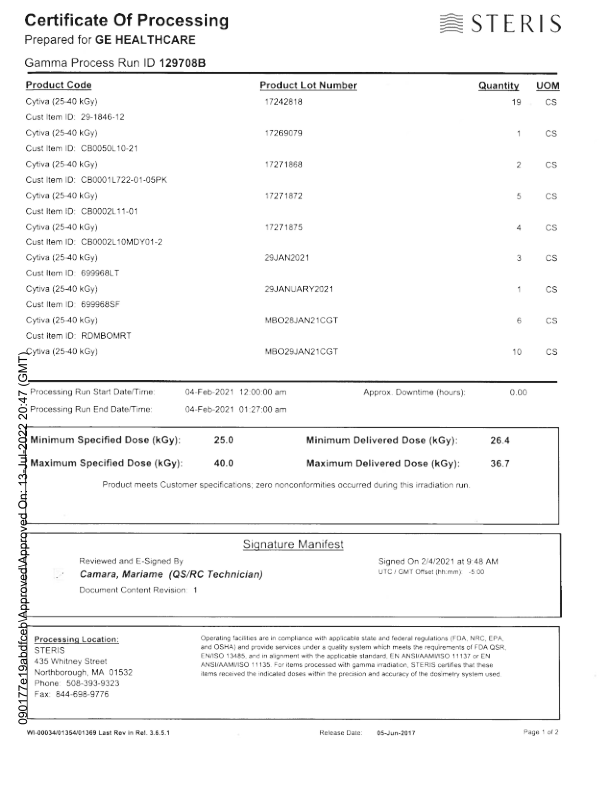

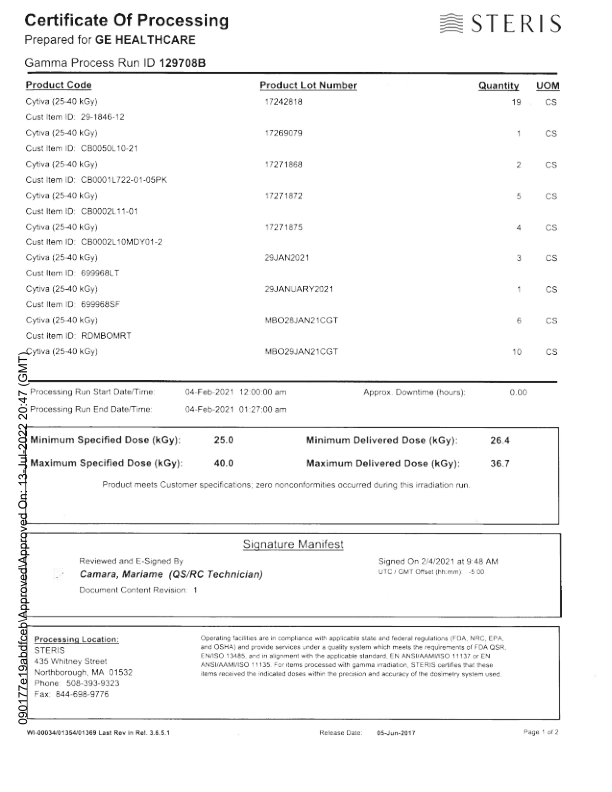

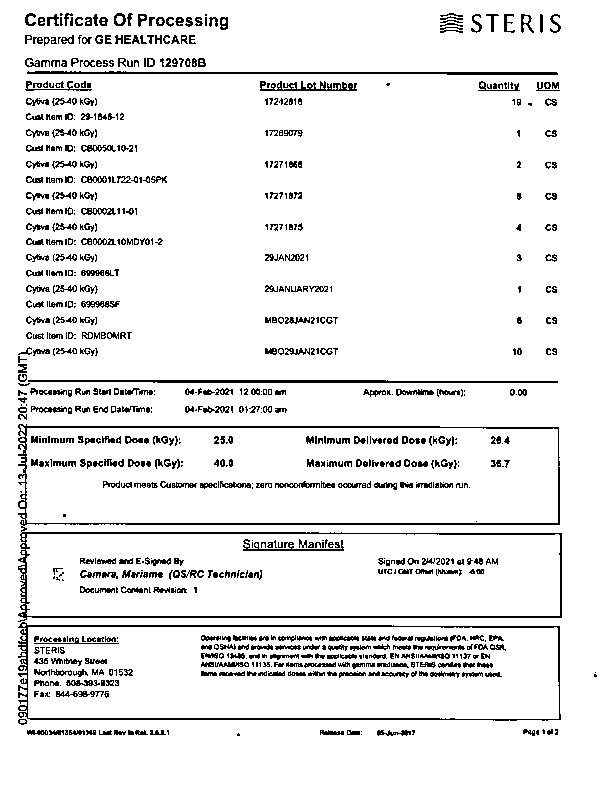

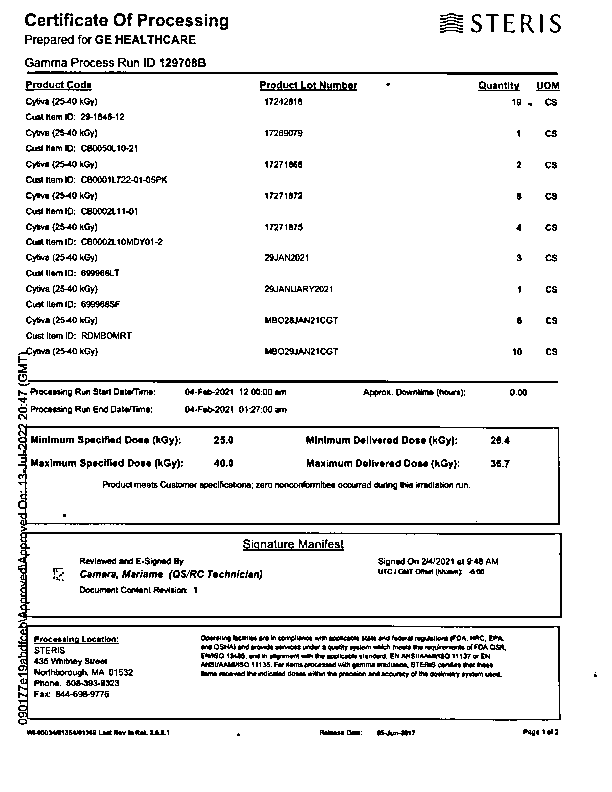

OCR Extracted Text:

Certificate Of Processing ZSSTERIS

 

 

 

 

 

 

Prepared for GE HEALTHCARE
Gamma Process Run ID 1297088,
Product Cot ProductLot Number * ‘Quactity YOM
ofa 54046" ze ws
Coattem 1: 29184842
ye 840 ay) 209079 1 6s
‘et Mam: Ceb050,10-21
vit 2540 1691 zie 2
(ct Mart0: CAO00NL722.01-05
Cyn 2840 100) wane + 8
cat mario: 00211101
pera 2840 104) sams 4c
Cua temiD: CA006a AONDYON 2
oa @540 46H) zuananas s 6s
ut aria: omoee6LT
pee 2840 Kay) souanuanraons 1 6
Cae aeD: 6re908S
pon 2540 by) Mao2euAnzIcGT 6 es
Cust em 0: ROMBONRT
(rm aaonoy weozsuanatecT w ce
z
=
i Prana Run tne: oe ra20et 12 0800 wn “apex. Downne (ne 0.00
Sirrocreina Rn ensDateene: OL Fob z0EY 012700 am
Minimum Specified Deas AGy}: 25. Minimum Delivered Dose (KGy: 20.4
Maximum Specified Dove KGy): 40.0, Maximum Delivered Dose (hGy): 387

Productos Customer aeelcston; zara nencefonites conrad aug Be raion in

 

 

 

 

=
‘lanalwe Manes

Aetna an Spy Serndon cinnamon
Ge Cama teriame (05/Re Techoican cro an

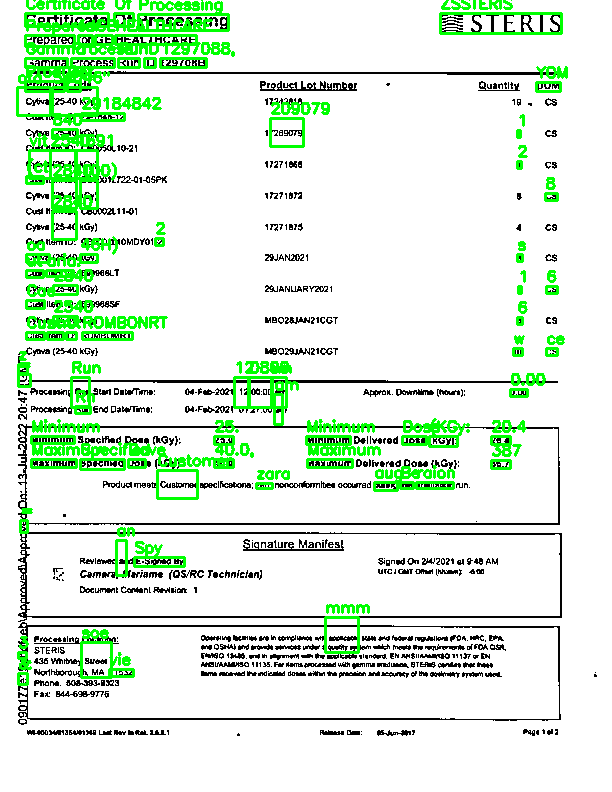

In [16]:
!apt install -y tesseract-ocr  # Install Tesseract OCR
!pip install pymupdf pytesseract opencv-python pillow numpy  # Install required Python libraries
import cv2
import pytesseract
import fitz  # PyMuPDF
import numpy as np
from PIL import Image
# Load the scanned PDF
pdf_path = "/content/pharmaceutical-sdf-page4-certificate-processing.pdf"  # Update this path if needed
doc = fitz.open(pdf_path)

# Extract text from the first page using a standard method (this will fail for scanned PDFs)
page = doc[0]  # Get the first page
text = page.get_text("text")  # Try extracting text

print("Extracted Text (Without OCR):")
print(text)
# Convert the first page to an image
pix = page.get_pixmap()
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

# Display the image
display(img)
# Convert the image to grayscale
img = np.array(img)  # Convert PIL image to NumPy array
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Display the grayscale image
display(Image.fromarray(gray))

# Apply adaptive thresholding to enhance contrast
gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# Display the processed image
display(Image.fromarray(gray))

# Apply Bilateral Filtering for noise reduction
gray = cv2.bilateralFilter(gray, 9, 75, 75)

# Display the processed image
display(Image.fromarray(gray))
 # Rotate 90 degrees clockwise
rotated = cv2.rotate(gray, cv2.ROTATE_90_CLOCKWISE)

# Rotate 180 degrees
rotated = cv2.rotate(gray, cv2.ROTATE_180)

# Rotate 90 degrees counter-clockwise
rotated = cv2.rotate(gray, cv2.ROTATE_90_COUNTERCLOCKWISE)
# Run OCR on the preprocessed image
custom_config = r'--oem 3 -l eng'
ocr_text = pytesseract.image_to_string(gray, config=custom_config)

# Print extracted text
print("OCR Extracted Text:\n")
print(ocr_text)

# Remove excessive newlines and extra spaces
ocr_text = " ".join(ocr_text.split())
print("Cleaned OCR Text:\n", ocr_text)

import re

# Fix common OCR errors in pharmaceutical documents
ocr_text = re.sub(r'\bL0T\b', 'LOT', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bC0A\b', 'COA', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bCERT1FICATE\b', 'CERTIFICATE', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bEXP1RATION\b', 'EXPIRATION', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'[^a-zA-Z0-9\s,.%-]', '', ocr_text) # Remove unwanted symbols

print("Corrected OCR Text:\n", ocr_text)

# The following section was problematic and has been removed:
# import re
# import fitz  # PyMuPDF
# import pytesseract
# from PIL import Image
# import io

# # Extract text via OCR since it's a scanned PDF
# doc = fitz.open("pharmaceutical-sdf-page4-certificate-processing__4_.pdf") # This file does not exist
# page = doc[0]
# pix = page.get_pixmap(dpi=300)
# img = Image.open(io.BytesIO(pix.tobytes("png")))
# ocr_text = pytesseract.image_to_string(img) # This overwrites the cleaned ocr_text
# doc.close()

# Extract Gamma Process Run ID (using the corrected ocr_text)
run_id_match = re.search(r"Gamma\s*Process\s*Run\s*ID[:\s]*([\w\-]+)", ocr_text, re.IGNORECASE)
if run_id_match:
    run_id = run_id_match.group(1)
    print(f"Extracted Gamma Process Run ID: {run_id}")
else:
    print("WARNING: Gamma Process Run ID not found")

# Extract Product Lot Numbers (finds all lot numbers in the text)
lot_matches = re.findall(r"\b(\d{8})\b", ocr_text)
if lot_matches:
    print(f"Extracted Product Lot Numbers: {lot_matches}")
else:
    print("WARNING: No Product Lot Numbers found")

# Extract Minimum Specified Dose
min_spec_match = re.search(r"Minimum\s*Specified\s*Dose\s*\(?kGy\)?[;:\s]*([\d.]+)", ocr_text, re.IGNORECASE)
if min_spec_match:
    min_spec_dose = min_spec_match.group(1)
    print(f"Extracted Minimum Specified Dose (kGy): {min_spec_dose}")
else:
    print("WARNING: Minimum Specified Dose not found")

# Extract Minimum Delivered Dose
min_del_match = re.search(r"Minimum\s*Delivered\s*Dose\s*\(?kGy\)?[;:\s]*([\d.]+)", ocr_text, re.IGNORECASE)
if min_del_match:
    min_del_dose = min_del_match.group(1)
    print(f"Extracted Minimum Delivered Dose (kGy): {min_del_dose}")
else:
    print("WARNING: Minimum Delivered Dose not found")

# Extract Maximum Specified Dose
max_spec_match = re.search(r"Maximum\s*Specified\s*Dose\s*\(?kGy\)?[;:\s]*([\d.]+)", ocr_text, re.IGNORECASE)
if max_spec_match:
    max_spec_dose = max_spec_match.group(1)
    print(f"Extracted Maximum Specified Dose (kGy): {max_spec_dose}")
else:
    print("WARNING: Maximum Specified Dose not found")

# Extract Maximum Delivered Dose
max_del_match = re.search(r"Maximum\s*Delivered\s*Dose\s*\(?kGy\)?[;:\s]*([\d.]+)", ocr_text, re.IGNORECASE)
if max_del_match:
    max_del_dose = max_del_match.group(1)
    print(f"Extracted Maximum Delivered Dose (kGy): {max_del_dose}")
else:
    print("WARNING: Maximum Delivered Dose not found")

import cv2
from PIL import Image

# Get detailed OCR results with bounding box data
ocr_data = pytesseract.image_to_data(gray, config=custom_config, output_type=pytesseract.Output.DICT)

# Convert image to OpenCV BGR format
img_bgr = cv2.cvtColor(gray, cv2.COLOR_RGB2BGR)

# Get OpenCV image height for correct y-coordinate transformation
page_height = gray.shape[0]

# Define confidence threshold (ignore low-confidence words)
confidence_threshold = 40

# 📌 Step 9.1: Loop through Extracted OCR Words & Draw Bounding Boxes
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    x, y, w, h = ocr_data["left"][i], ocr_data["top"][i], ocr_data["width"][i], ocr_data["height"][i]
    conf = int(ocr_data["conf"][i])  # Convert confidence to int

    # Ignore empty words & low-confidence OCR text
    if not word or conf < confidence_threshold:
        continue

    # Draw bounding box
    cv2.rectangle(img_bgr, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img_bgr, word, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 📌 Step 9.2: Convert Back to RGB & Display the Image
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
display(Image.fromarray(img_rgb))